In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import warnings

import pandas as pd


# Load configuration
sys.path.append("../")
warnings.filterwarnings("ignore")

from utils import ouvrir_model


model = ouvrir_model()
model

Pipeline(steps=[('preprocessing',
                 FeatureUnion(transformer_list=[('encoding',
                                                 ColumnTransformer(remainder='passthrough',
                                                                   transformers=[('encoder',
                                                                                  OneHotEncoder(drop='first',
                                                                                                sparse_output=False),
                                                                                  ['Geography',
                                                                                   'Gender'])],
                                                                   verbose_feature_names_out=False)),
                                                ('churn_score',
                                                 ChurnProbabilityScore(threshold=0.7))])),
                ('classifier',
                 LGBMClassifier(is_unbalance=True, learning_rate=0.01,
                                max_depth=7, n_estimators=300, n_jobs=0,
                                num_leaves=225, random_state=0))])

In [4]:
# Load the data
X = pd.read_csv("../data/train_data.csv", index_col='ID')

# Feature 'CustomerId' est une erreur est doit être éliminé
X.drop(columns='CustomerId', inplace=True)

# Feature 'Surname' n´a aucune signification pour notre projet
X.drop(columns='Surname', inplace=True)

y_true = X.pop("Exited")
X = X.copy()

In [5]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
ID,,,,,,,,,,
37765,627,France,Male,28.0,7,131694.04,1,1.0,1.0,161205.61
130453,597,France,Male,34.0,2,0.00,2,0.0,1.0,181419.29
77297,724,France,Male,39.0,7,0.00,2,1.0,1.0,100862.54
40858,663,Germany,Female,56.0,5,118577.24,3,1.0,0.0,61164.45
19804,627,France,Female,33.0,5,0.00,2,1.0,1.0,103737.82


In [6]:
y_pred_proba = model.predict_proba(X)[:, 1]  # Probabilités pour la classe 1
y_pred = (y_pred_proba >= 0.6).astype(int)   # Utilise ton seuil optimal

# Faux positifs = prédits 1 mais réels 0
false_positives = X[(y_pred == 1) & (y_true == 0)]


In [7]:
true_negatives = X[(y_pred == 0) & (y_true == 0)]

# Moyennes ou distributions
fp_stats = false_positives.describe()
tn_stats = true_negatives.describe()

# Comparaison
diff = fp_stats.loc['mean'] - tn_stats.loc['mean']


In [8]:
# Seuil optimal trouvé (ex : 0.6)
threshold = 0.6
y_pred = (y_pred_proba >= threshold).astype(int)

# Masques
fp_mask = (y_pred == 1) & (y_true == 0)
fn_mask = (y_pred == 0) & (y_true == 1)
tp_mask = (y_pred == 1) & (y_true == 1)
tn_mask = (y_pred == 0) & (y_true == 0)


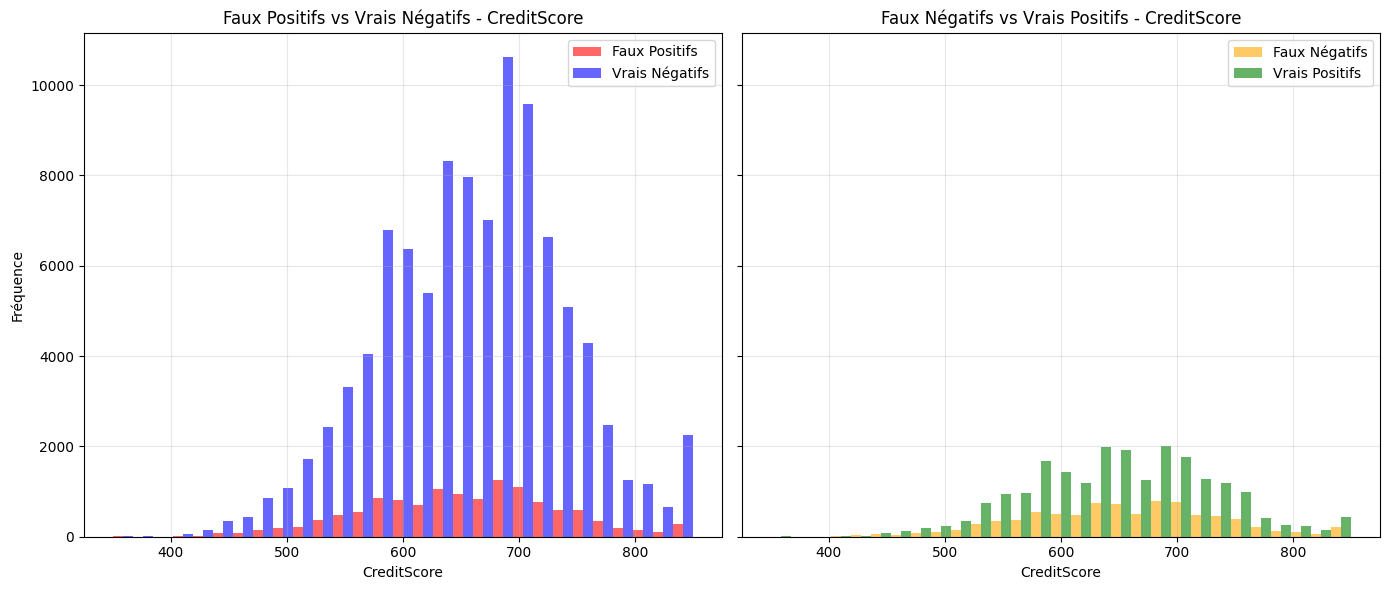

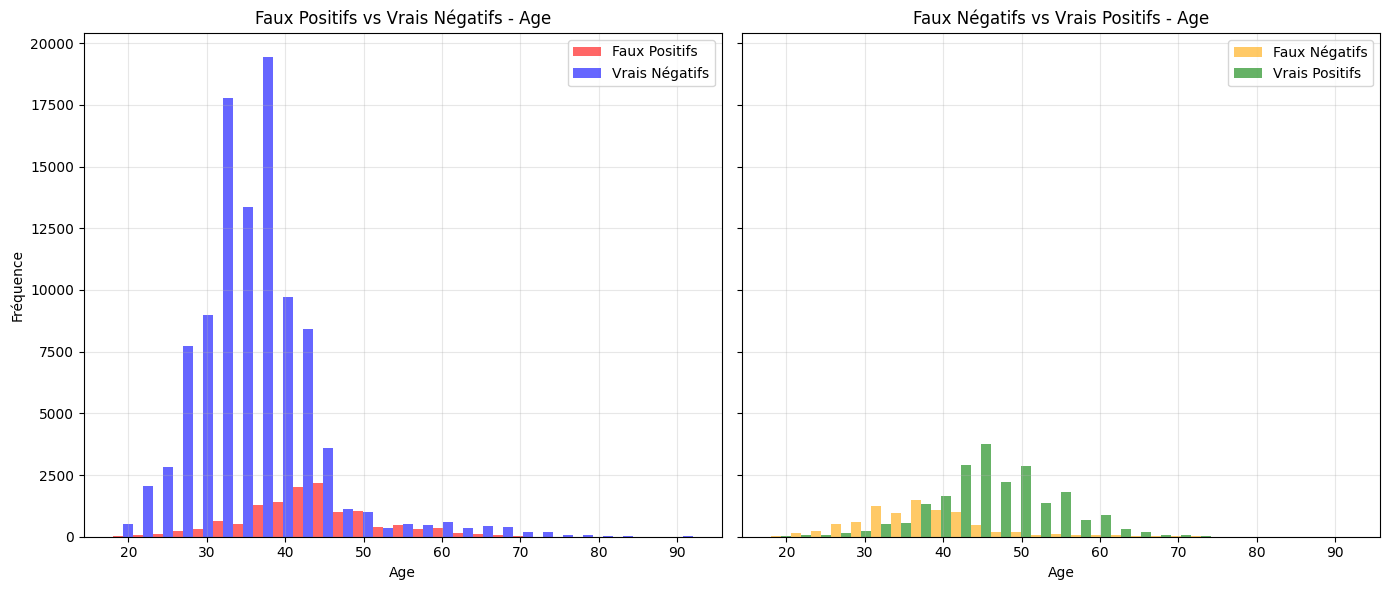

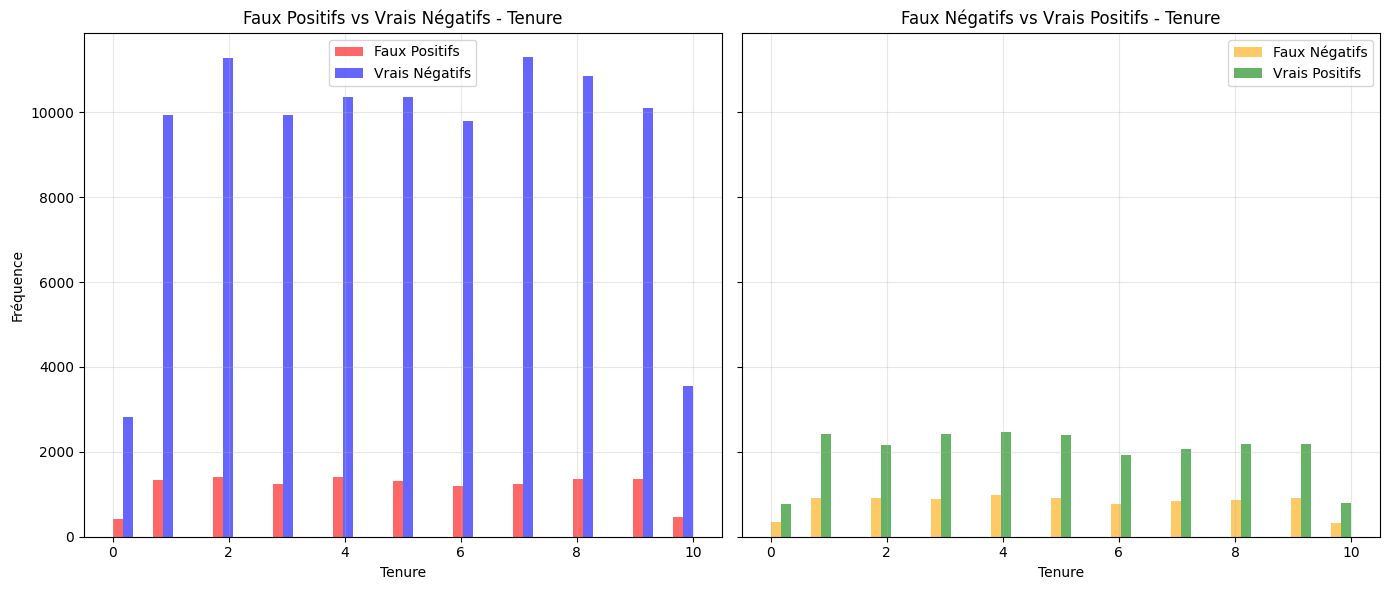

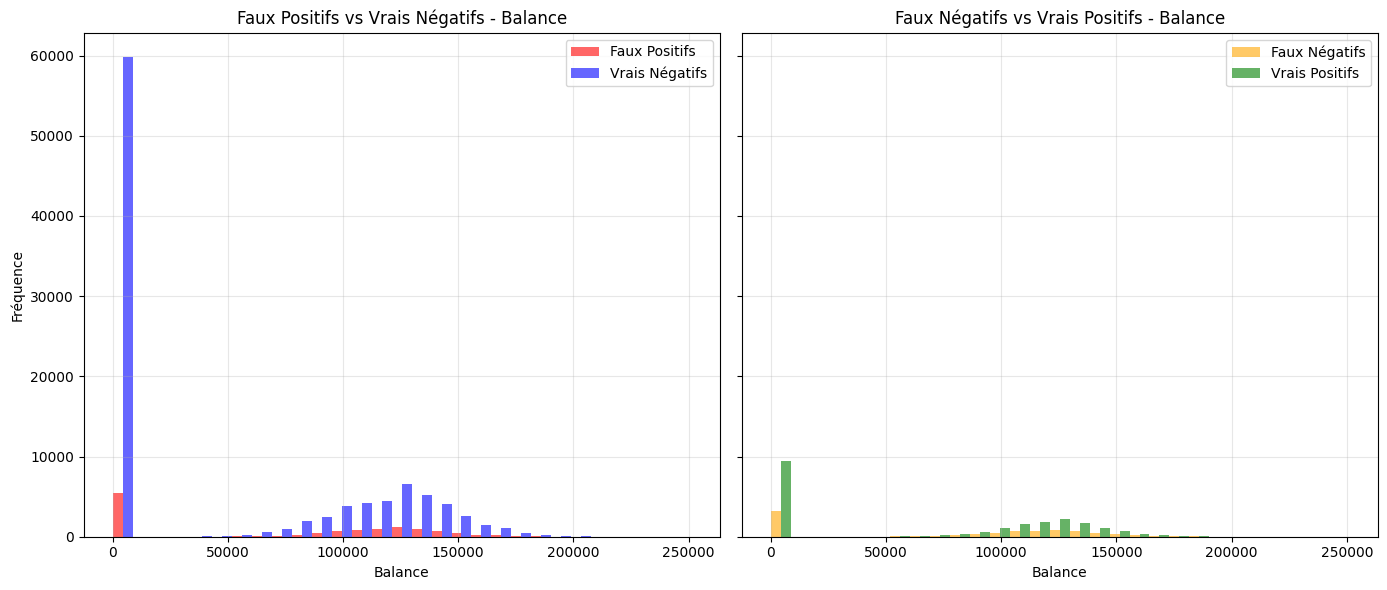

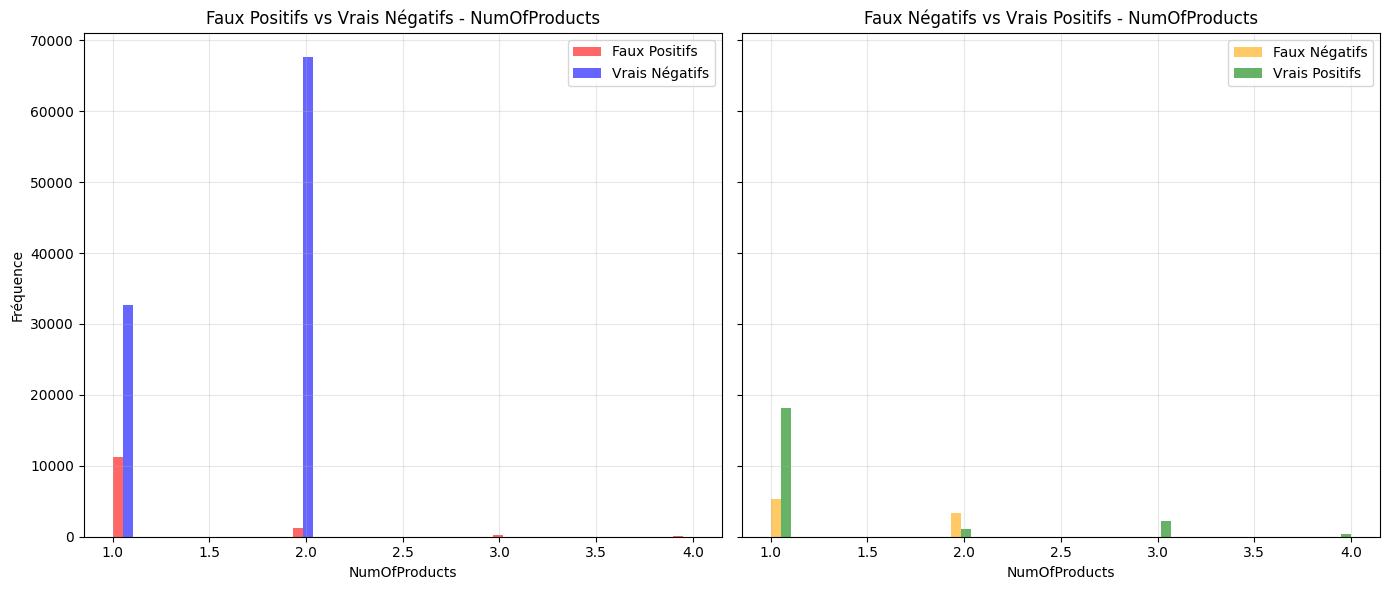

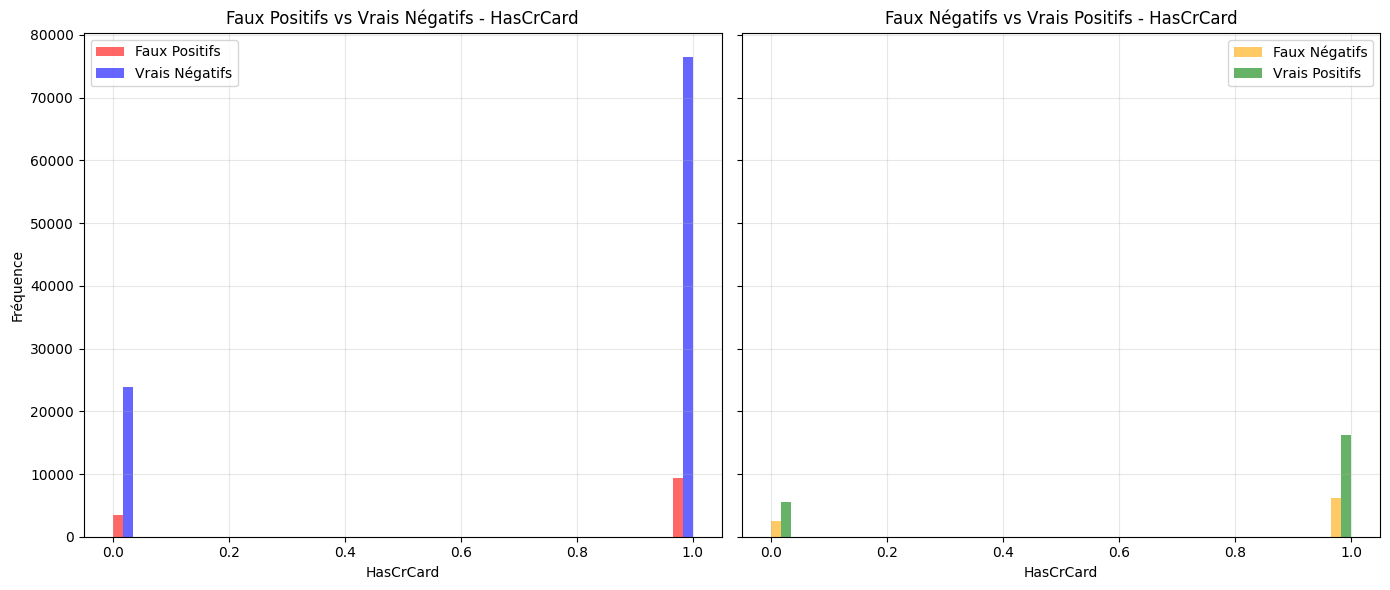

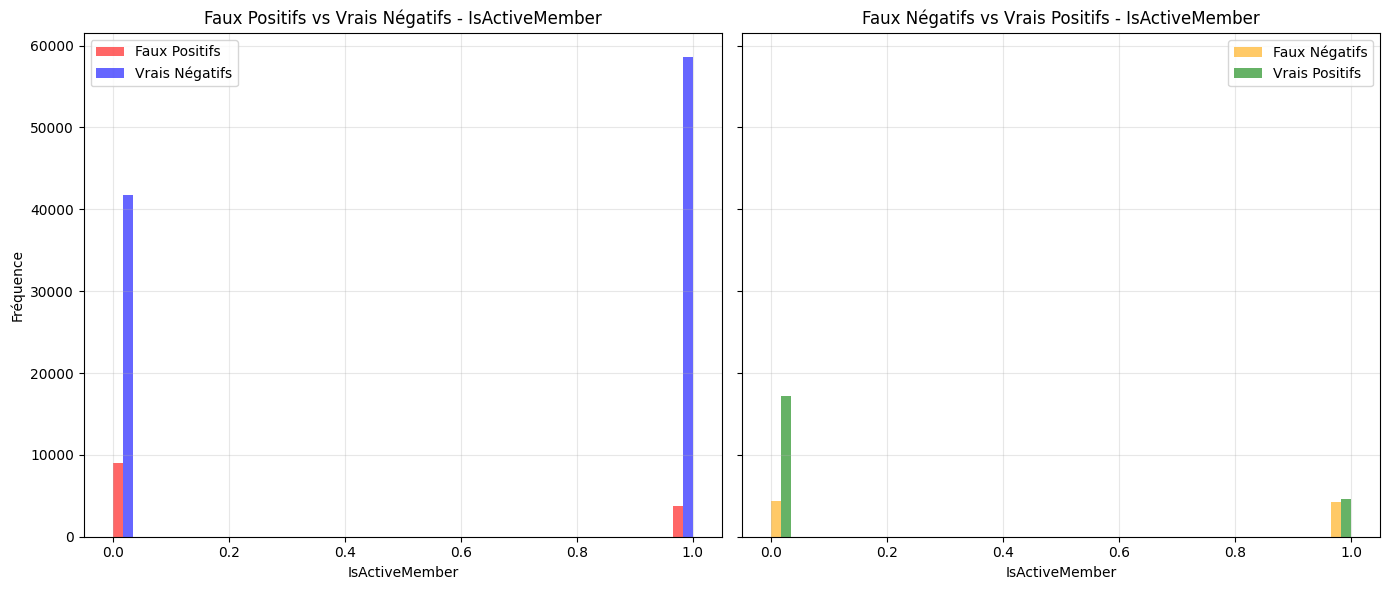

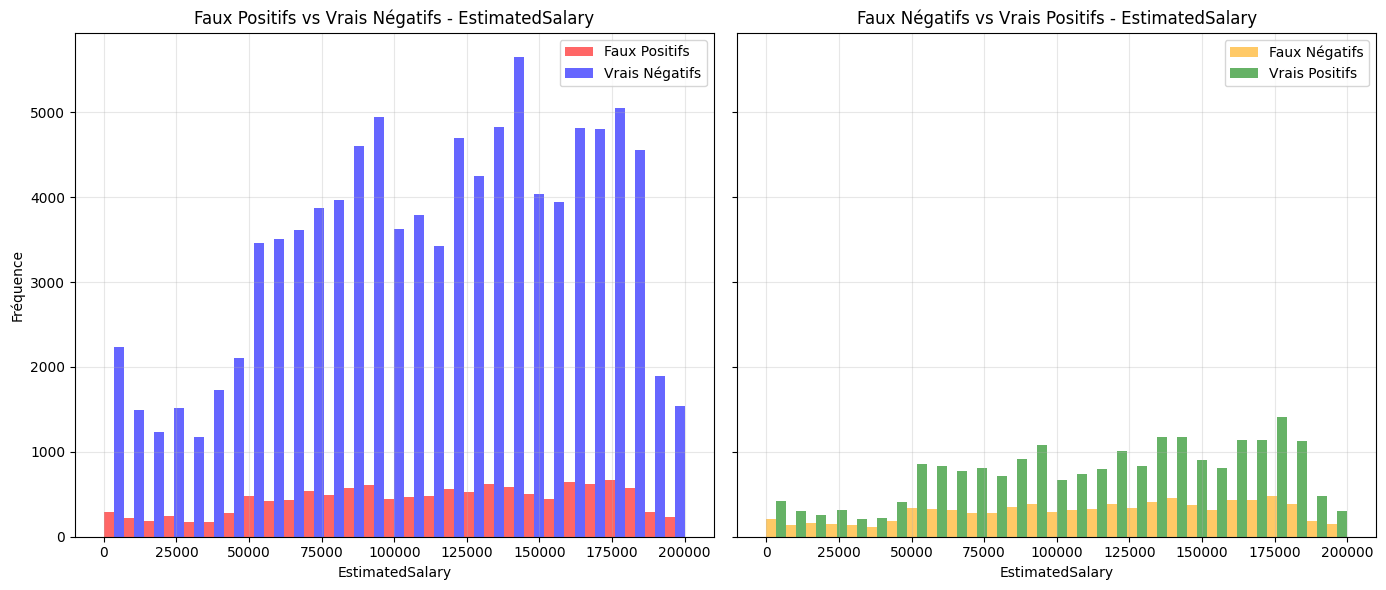

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Filtrer uniquement les colonnes numériques
numeric_columns = X.select_dtypes(include=['number']).columns

# Amélioration de la visualisation avec des histogrammes côte à côte
for feature in numeric_columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    # Subplot 1 : Faux positifs et vrais négatifs
    bins = np.linspace(X[feature].min(), X[feature].max(), 30)
    width = (bins[1] - bins[0]) / 2  # Ajuster la largeur des barres pour éviter la superposition
    axes[0].bar(bins[:-1], np.histogram(X.loc[fp_mask, feature], bins=bins)[0], width=width, alpha=0.6, color='red', label='Faux Positifs', align='edge')
    axes[0].bar(bins[:-1] + width, np.histogram(X.loc[tn_mask, feature], bins=bins)[0], width=width, alpha=0.6, color='blue', label='Vrais Négatifs', align='edge')
    axes[0].set_title(f"Faux Positifs vs Vrais Négatifs - {feature}")
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel("Fréquence")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Subplot 2 : Faux négatifs et vrais positifs
    axes[1].bar(bins[:-1], np.histogram(X.loc[fn_mask, feature], bins=bins)[0], width=width, alpha=0.6, color='orange', label='Faux Négatifs', align='edge')
    axes[1].bar(bins[:-1] + width, np.histogram(X.loc[tp_mask, feature], bins=bins)[0], width=width, alpha=0.6, color='green', label='Vrais Positifs', align='edge')
    axes[1].set_title(f"Faux Négatifs vs Vrais Positifs - {feature}")
    axes[1].set_xlabel(feature)
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Ajustement de la mise en page
    plt.tight_layout()
    plt.show()

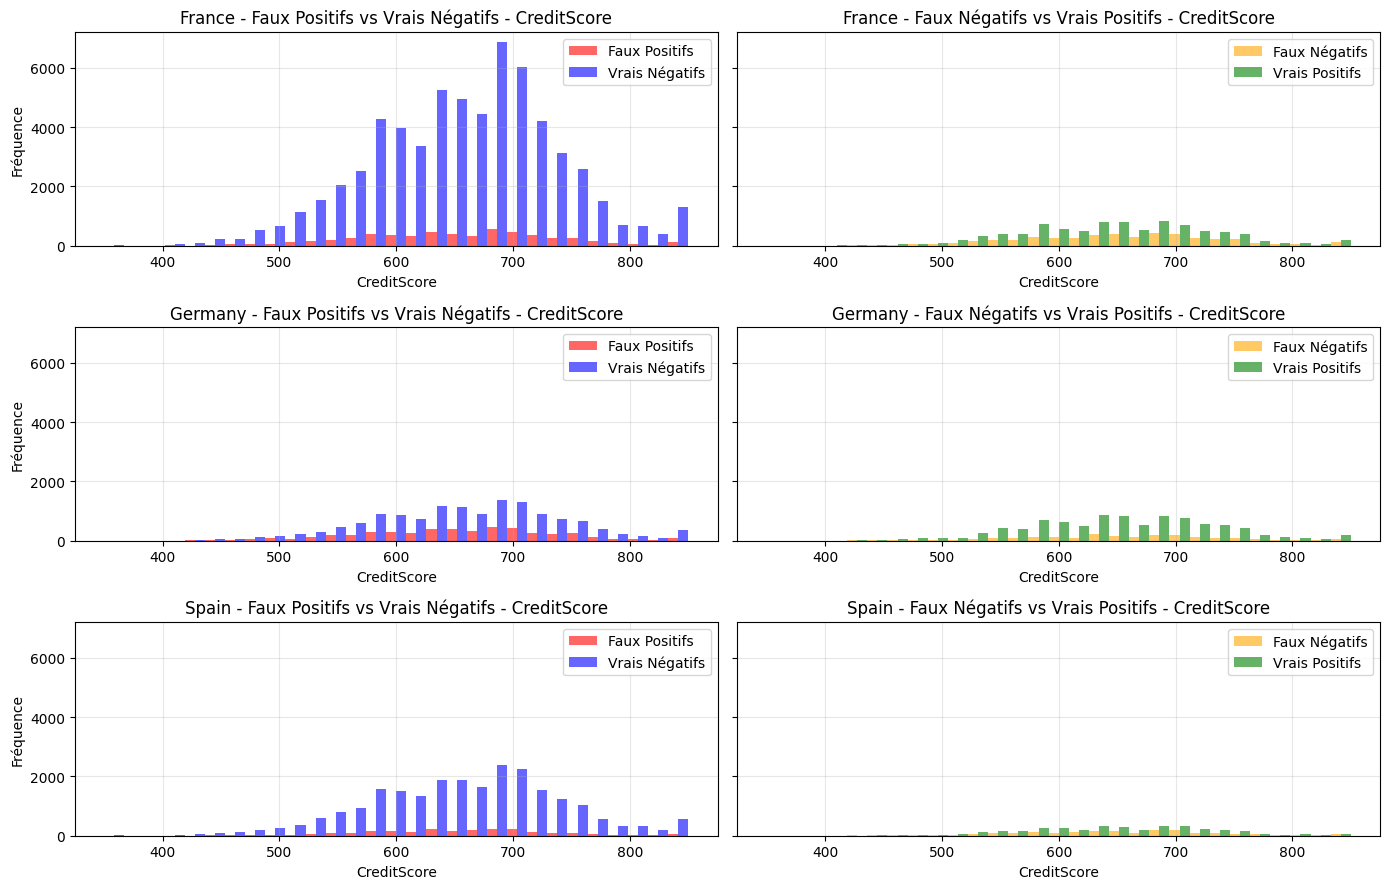

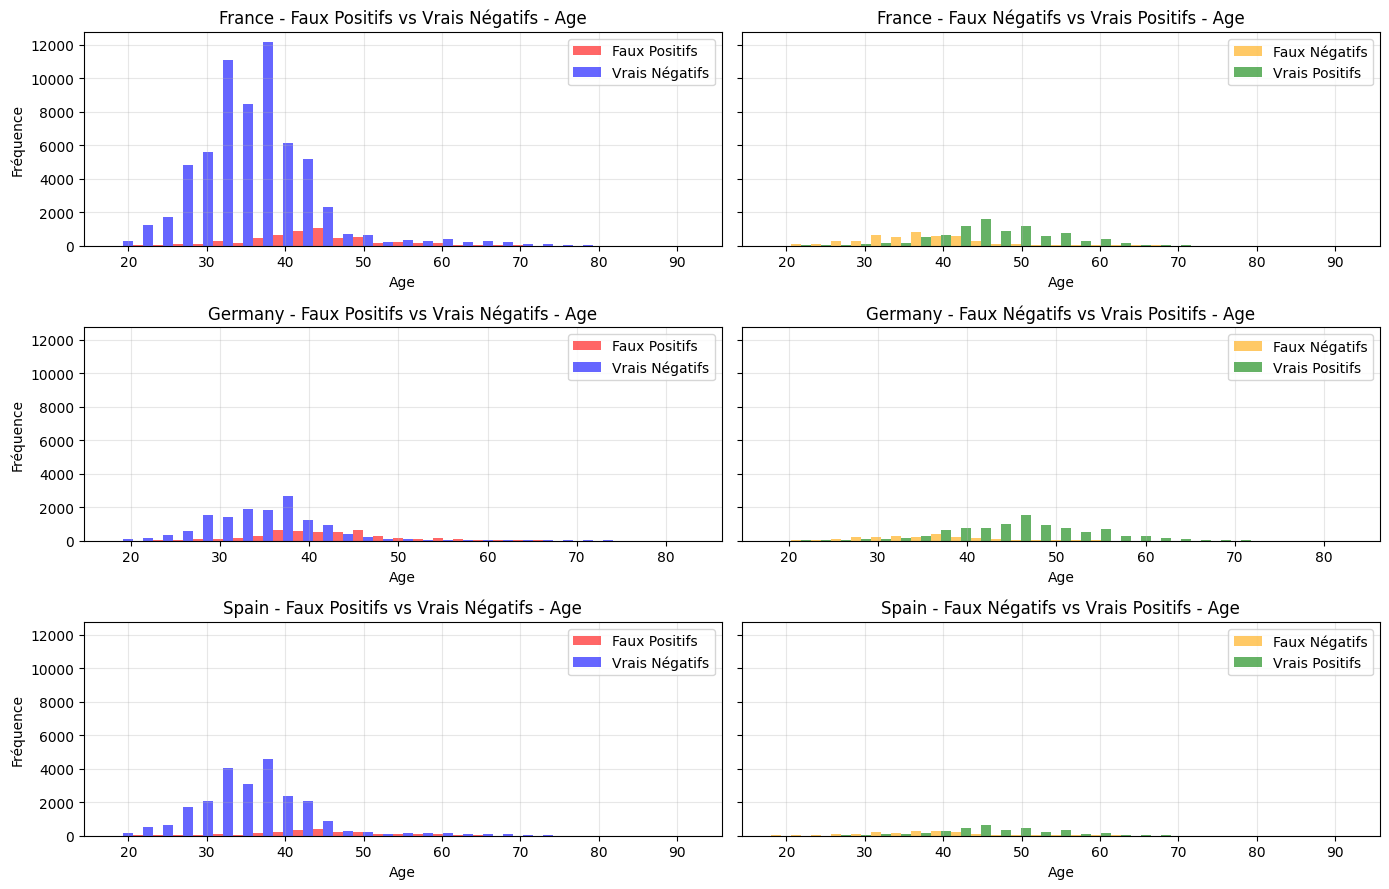

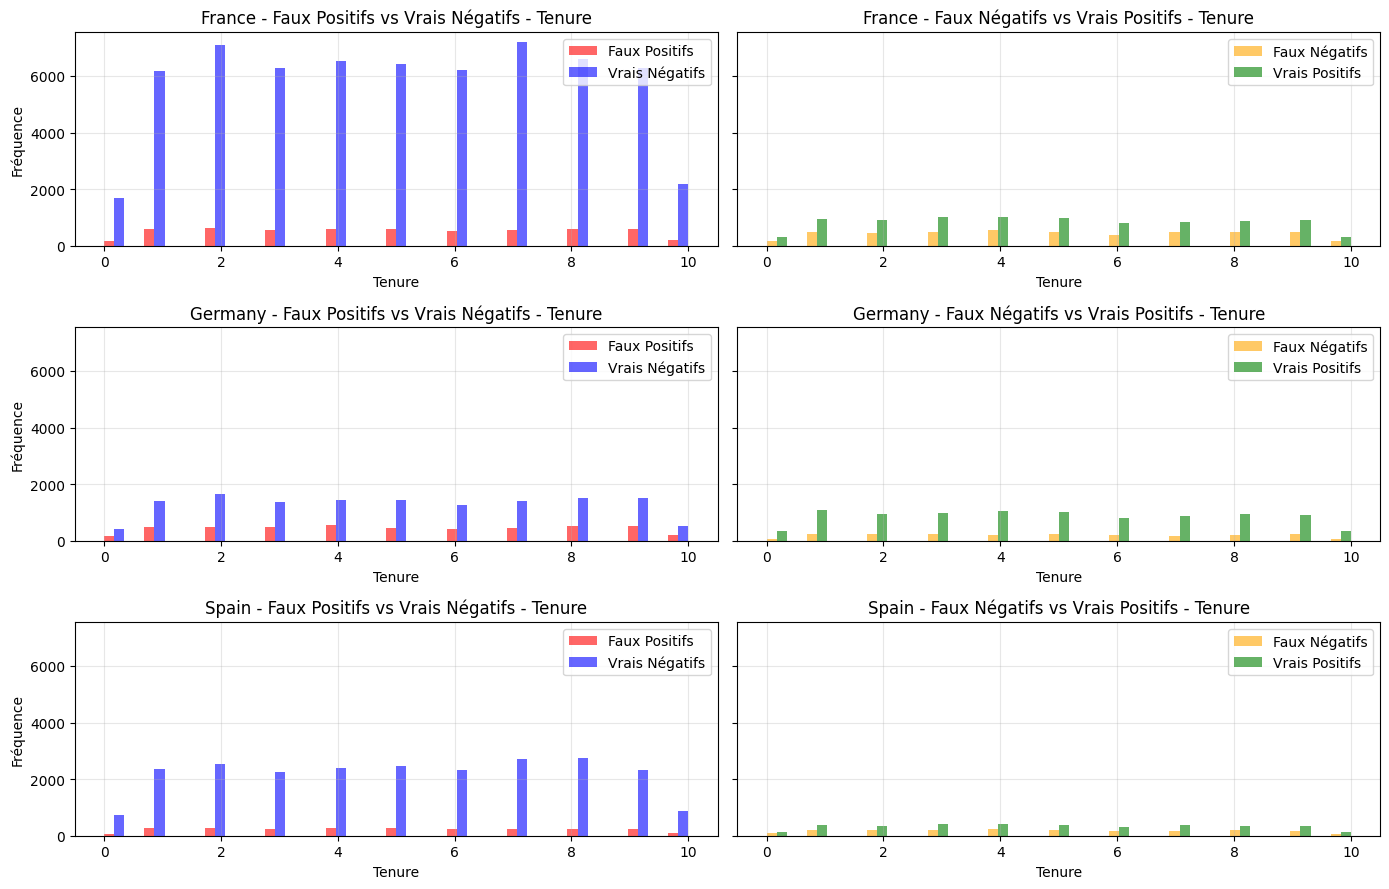

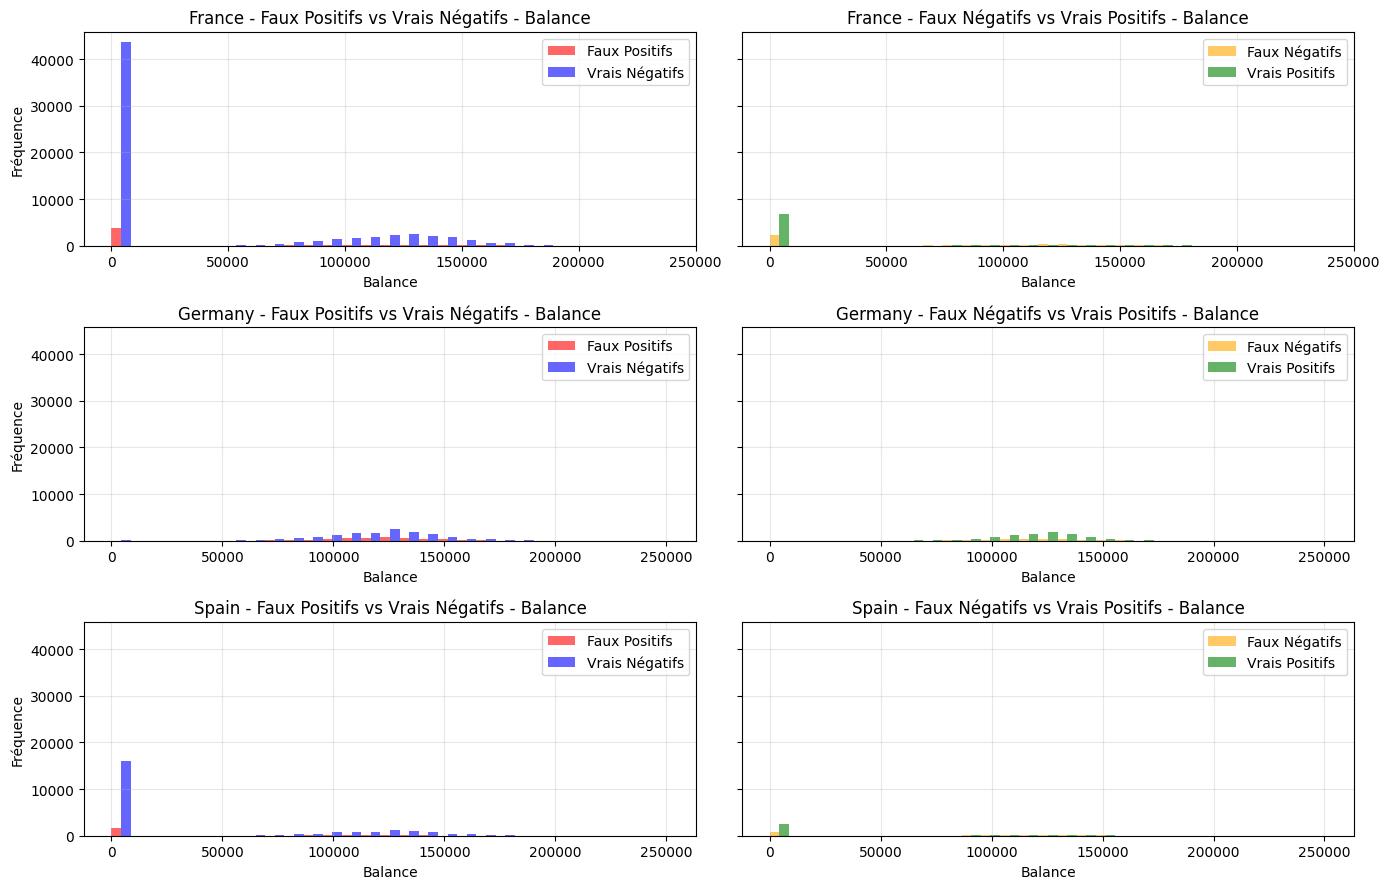

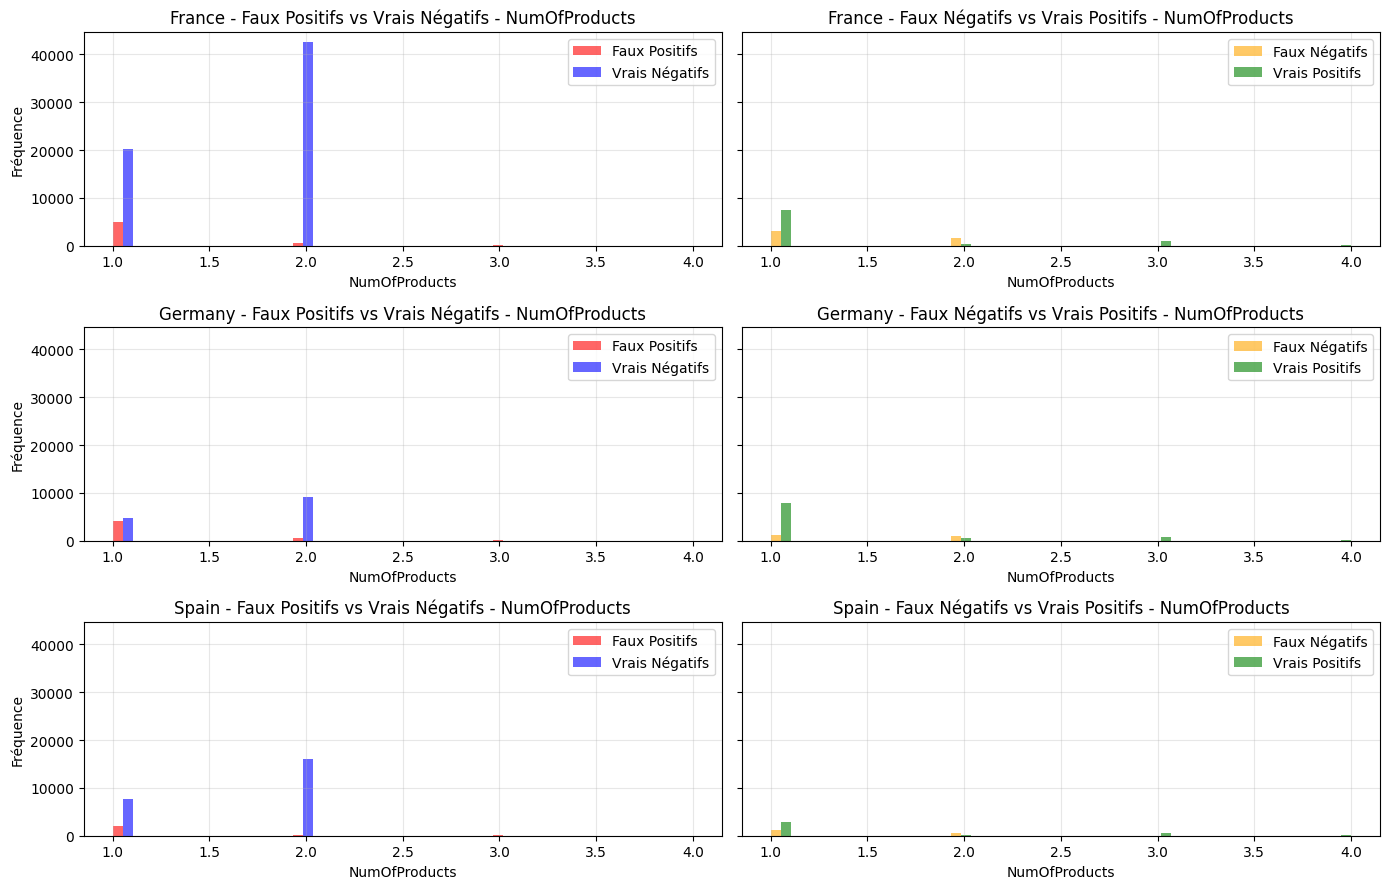

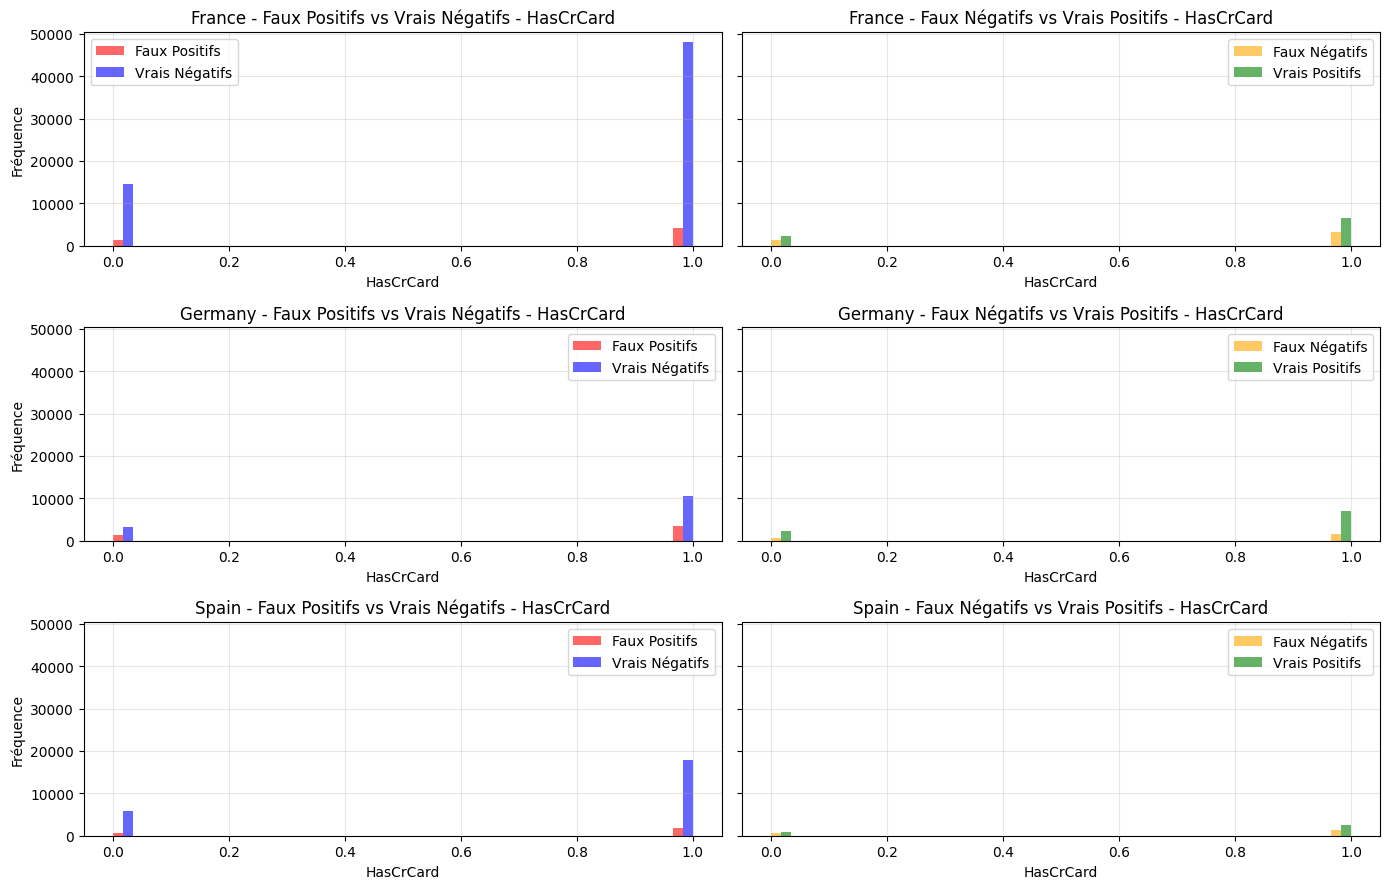

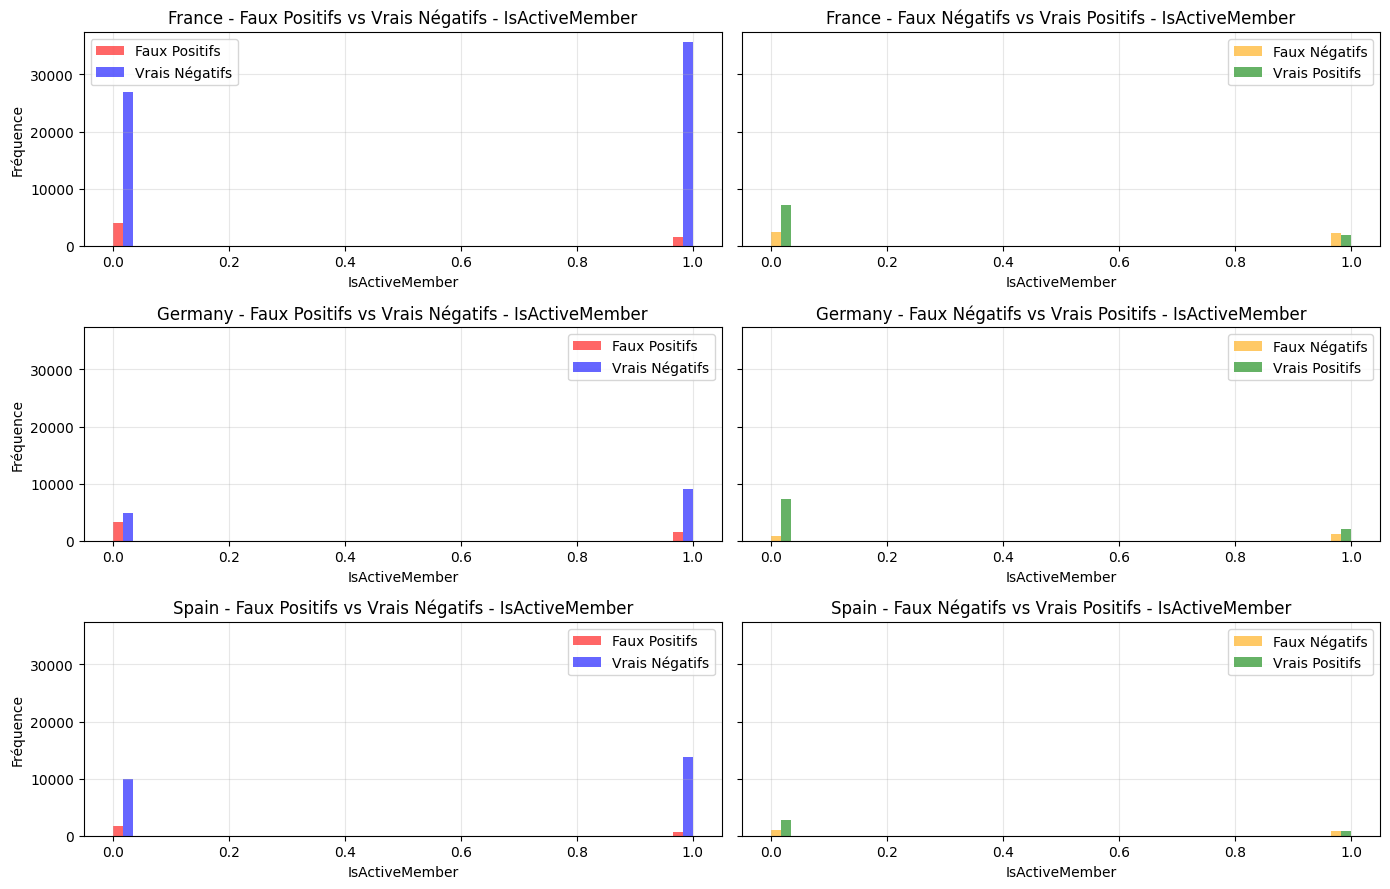

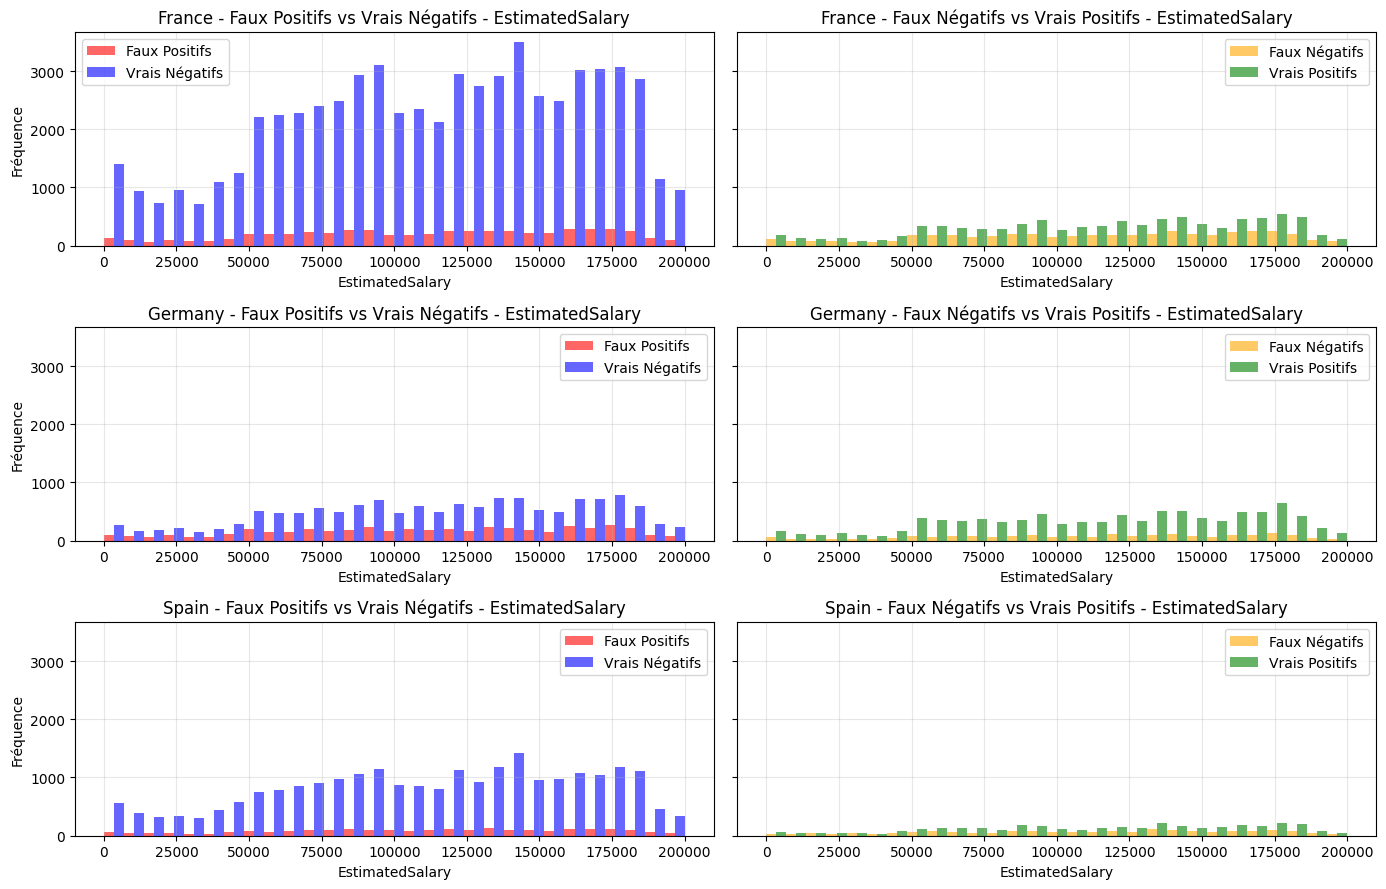

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Filtrer uniquement les colonnes numériques
numeric_columns = X.select_dtypes(include=['number']).columns

# Liste des pays
countries = X['Geography'].unique()

# Amélioration de la visualisation avec des histogrammes par pays
for feature in numeric_columns:
    fig, axes = plt.subplots(len(countries), 2, figsize=(14, 3 * len(countries)), sharey=True)  # Réduction de la hauteur des subplots
    
    for i, country in enumerate(countries):
        X_country = X[X['Geography'] == country]
        fp_mask_country = fp_mask & (X['Geography'] == country)
        fn_mask_country = fn_mask & (X['Geography'] == country)
        tp_mask_country = tp_mask & (X['Geography'] == country)
        tn_mask_country = tn_mask & (X['Geography'] == country)
        
        bins = np.linspace(X_country[feature].min(), X_country[feature].max(), 30)
        width = (bins[1] - bins[0]) / 2  # Ajuster la largeur des barres pour éviter la superposition
        
        # Subplot 1 : Faux positifs et vrais négatifs
        axes[i, 0].bar(bins[:-1], np.histogram(X_country.loc[fp_mask_country, feature], bins=bins)[0], width=width, alpha=0.6, color='red', label='Faux Positifs', align='edge')
        axes[i, 0].bar(bins[:-1] + width, np.histogram(X_country.loc[tn_mask_country, feature], bins=bins)[0], width=width, alpha=0.6, color='blue', label='Vrais Négatifs', align='edge')
        axes[i, 0].set_title(f"{country} - Faux Positifs vs Vrais Négatifs - {feature}")
        axes[i, 0].set_xlabel(feature)
        axes[i, 0].set_ylabel("Fréquence")
        axes[i, 0].legend()
        axes[i, 0].grid(alpha=0.3)
        
        # Subplot 2 : Faux négatifs et vrais positifs
        axes[i, 1].bar(bins[:-1], np.histogram(X_country.loc[fn_mask_country, feature], bins=bins)[0], width=width, alpha=0.6, color='orange', label='Faux Négatifs', align='edge')
        axes[i, 1].bar(bins[:-1] + width, np.histogram(X_country.loc[tp_mask_country, feature], bins=bins)[0], width=width, alpha=0.6, color='green', label='Vrais Positifs', align='edge')
        axes[i, 1].set_title(f"{country} - Faux Négatifs vs Vrais Positifs - {feature}")
        axes[i, 1].set_xlabel(feature)
        axes[i, 1].legend()
        axes[i, 1].grid(alpha=0.3)
    
    # Ajustement de la mise en page
    plt.tight_layout()
    plt.show()